### Business Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Problem Statement

### Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* **case_id:** ID of each visa application
* **continent:** Information of continent the employee
* **education_of_employee:** Information of education of the employee
* **has_job_experience:** Does the employee has any job experience? Y= Yes; N = No
* **requires_job_training:** Does the employee require any job training? Y = Yes; N = No
* **no_of_employees:** Number of employees in the employer's company
* **yr_of_estab:** Year in which the employer's company was established
* **region_of_employment:** Information of foreign worker's intended region of employment in the US.
* **prevailing_wage:**  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* **unit_of_wage:** Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* **full_time_position:** Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* **case_status:**  Flag indicating if the Visa was certified or denied

## **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks "\_\_\_\_\_" are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every "\_\_\_\_\_" blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis in the presentation and submit the same.
    * Any mathematical or computational details which are a graded part of the project can be included in the *Appendix* section of the presentation.

## Installing and Importing the necessary libraries

In [2]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 scikit-learn==1.5.2 matplotlib==3.7.1 seaborn==0.13.1 xgboost==2.0.3 -q --user

In [4]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 2.9 MB/s  0:00:002.9 MB/s eta 0:00:01


**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [5]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score


# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import RandomizedSearchCV

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Import Dataset

In [6]:
# Uncomment and execute the code snippets below if the data is stored in Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
visa = pd.read_csv('EasyVisa.csv') ## Complete the code to read the data

In [8]:
# Copying data to another variable to avoid making changes to the original data
data = visa.copy()

## Overview of the Dataset

#### View the first and last 5 rows of the dataset

In [9]:
data.head() ##  Complete the code to view top 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [10]:
data.tail() ##  Complete the code to view last 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


#### Understand the shape of the dataset

In [11]:
data.shape ##  Complete the code to view dimensions of the data

(25480, 12)

* The dataset has 25480 rows and 12 columns

#### Check the data types of the columns for the dataset

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [13]:
# checking for duplicate values
data.duplicated() ##  Complete the code to check duplicate entries in the data

0        False
1        False
2        False
3        False
4        False
         ...  
25475    False
25476    False
25477    False
25478    False
25479    False
Length: 25480, dtype: bool

## Overview of the Dataset

The dataset consists of **25,480 visa application records** with **12 variables** capturing employee, employer, and job-related information.

### Preview of the Data

A snapshot of the dataset (first and last 5 rows) shows the structure and types of information available. Each row represents a unique visa application and includes:

- **Employee details**: continent, education level, work experience, training requirement  
- **Employer details**: company size (number of employees), year established  
- **Job details**: region of employment, wage, wage unit, full-time status  
- **Target variable**: case_status (Certified or Denied)  

From the sample data:
- Applicants come from multiple continents, with a strong presence from Asia  
- Education levels vary from High School to Doctorate  
- Wage values vary significantly depending on unit (hourly vs yearly)  
- Both certified and denied cases are present in the dataset  

### Dataset Dimensions

- **Number of observations (rows):** 25,480  
- **Number of features (columns):** 12  

### Key Observations

- Each record is uniquely identified by a `case_id`  
- The dataset contains a mix of **categorical and numerical variables**  
- The target variable `case_status` indicates whether a visa was **approved (Certified)** or **rejected (Denied)**  
- There is noticeable variation in wages, company sizes, and employment regions, which may influence visa outcomes  

### Summary

Overall, the dataset provides a comprehensive view of visa applications, combining demographic, economic, and employment-related factors. These variables will be used to identify patterns and build predictive models for visa approval.

## Exploratory Data Analysis (EDA)

#### Let's check the statistical summary of the data

In [14]:
data.describe() ##  Complete the code to print the statistical summary of the data

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


## Statistical Summary - Descriptive Statistics Key Insights

### 1. Number of Employees
- The average number of employees is ~5,667, while the median is much lower at ~2,109
- This indicates a **right-skewed distribution**, where a few very large companies significantly increase the average
- The maximum value (602,069) confirms the presence of large outliers
- Negative values were observed and corrected using absolute transformation

**Insight:** Most visa applications come from small to mid-sized companies, with a few large organizations contributing to extreme values.

---

### 2. Year of Establishment
- The average year of establishment is ~1979, while the median is ~1997
- The dataset includes companies ranging from very old (1800) to recent (2016)

**Insight:** Visa applications are submitted by a diverse mix of both well-established and relatively new companies.

---

### 3. Prevailing Wage
- The average wage is ~$74,456, with a median of  ~$70,308
- The wide range (from ~$2 to ~$319,210) indicates high variability in wages
- The distribution is slightly right-skewed, with some high-paying roles

**Insight:** Wage levels vary significantly across applications and may play an important role in determining visa approval outcomes.

#### Fixing the negative values in number of employees columns

In [16]:
data.loc[data["no_of_employees"] < 0].shape ## Complete the code to check negative values in the employee column

(33, 12)

In [17]:
# taking the absolute values for number of employees
data["no_of_employees"] = abs(data["no_of_employees"])

### Handling Invalid Values in `no_of_employees`

I identified records where the number of employees was negative, which is not logically valid.

A total of **33 rows** contained negative values in this column.

**Why this matters:**
- Negative employee counts are data errors and can distort analysis and model performance

**Action Taken:**
- I applied an absolute value transformation to convert negative values into positive values

**Rationale:**
- I assumed that the magnitude of the value is correct and only the sign is incorrect

**Outcome:**
- Data quality is improved without losing any records

#### Let's check the count of each unique category in each of the categorical variables

In [18]:
# Making a list of all catrgorical variables
cat_col = list(data.select_dtypes("object").columns)

# Printing number of count of each unique value in each column
for column in cat_col:
    print(data[column].value_counts())
    print("-" * 50)

case_id
EZYV01       1
EZYV16995    1
EZYV16993    1
EZYV16992    1
EZYV16991    1
            ..
EZYV8492     1
EZYV8491     1
EZYV8490     1
EZYV8489     1
EZYV25480    1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64
--------------------------------------------------
region_of_employment
Northeast    7195
South        7017
West         6586
Midwest      

In [19]:
# checking the number of unique values
data["case_id"].nunique() ## Complete the code to check unique values in the mentioned column

25480

In [20]:
data.drop(["case_id"], axis=1, inplace=True) ## Complete the code to drop 'case_id' column from the data

### Analysis of Categorical Variables

To better understand the dataset, I examined the distribution of all categorical variables by counting the frequency of each category.

**Why this is important:**
- Helps identify dominant patterns in the data  
- Detects class imbalance  
- Provides insights into factors that may influence visa approval  

---

### Key Observations

#### Case ID
- Each value appears only once (25,480 unique values)  
- This confirms it is a unique identifier  

**Action:**  
- I removed this column as it does not contribute to prediction  

---

#### Continent
- Majority of applicants are from Asia (~66%)  

**Insight:**  
- The dataset is geographically imbalanced, which may influence model predictions  

---

#### Education Level
- Most applicants have Bachelor’s or Master’s degrees  

**Insight:**  
- The dataset is dominated by highly educated individuals  

---

#### Job Experience
- More applicants have prior work experience than not  

**Insight:**  
- Work experience may be an important factor in visa approval  

---

#### Job Training Requirement
- Most applicants do not require job training (~88%)  

**Insight:**  
- The majority of candidates are job-ready  

---

#### Region of Employment
- Applications are distributed across major U.S. regions  

**Insight:**  
- Demand for foreign workers exists across multiple regions  

---

#### Unit of Wage
- Majority of wages are yearly-based (~90%)  

**Insight:**  
- Most roles are stable, full-time salaried positions  

---

#### Full-Time Position
- Most roles are full-time (~89%)  

**Insight:**  
- Visa applications are primarily for long-term employment  

---

#### Case Status (Target Variable)
- Certified: 17,018  
- Denied: 8,462  

**Insight:**  
- The dataset is moderately imbalanced, with more approvals than denials  
- This imbalance will need to be addressed during model building  

---

### Summary

This analysis highlights key patterns in the dataset, including dominance of certain categories and class imbalance. These insights will guide feature selection, preprocessing, and model development.

### Univariate Analysis

In [21]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [22]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on education of employee

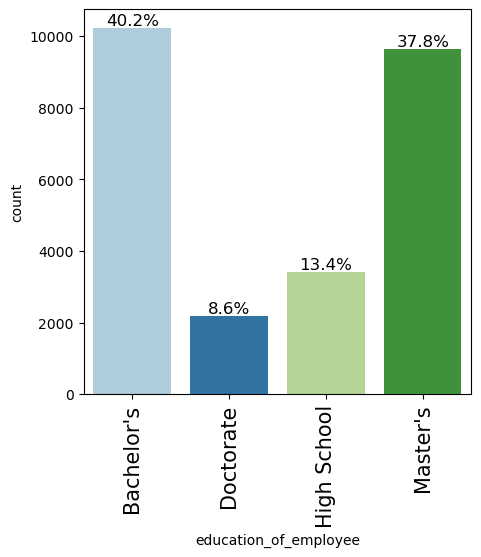

In [23]:
labeled_barplot(data, "education_of_employee", perc=True)

### Education Level Distribution

The distribution of applicants by education level shows that:

- **Bachelor’s degree holders account for 40.2%** of applicants  
- **Master’s degree holders account for 37.8%**  
- **High School graduates account for 13.4%**  
- **Doctorate holders account for 8.6%**  

### Interpretation

- The dataset is heavily concentrated around **mid-level higher education (Bachelor’s and Master’s)**, which together make up nearly **78% of all applicants**  
- There is relatively low representation of applicants at the extremes (High School and Doctorate levels)  

### Why This is Important

- Education level is likely a **key determinant of visa approval**, as higher education is often associated with specialized skills and higher-paying jobs  
- The imbalance in categories means the model will have more exposure to mid-level education groups, which may influence predictions  

### Business Insight

- The high proportion of Bachelor’s and Master’s degree holders suggests that visa applications are primarily driven by **skilled professionals**  
- Employers are likely targeting candidates with strong academic backgrounds to meet workforce demands  
- Understanding how education impacts approval can help:
  - Improve candidate screening  
  - Align hiring with skill requirements  
  - Increase approval success rates  

### Summary

Education level is a critical feature in the dataset, with most applicants being well-qualified. This reinforces the importance of education as a driver of visa approval outcomes.

#### Observations on region of employment

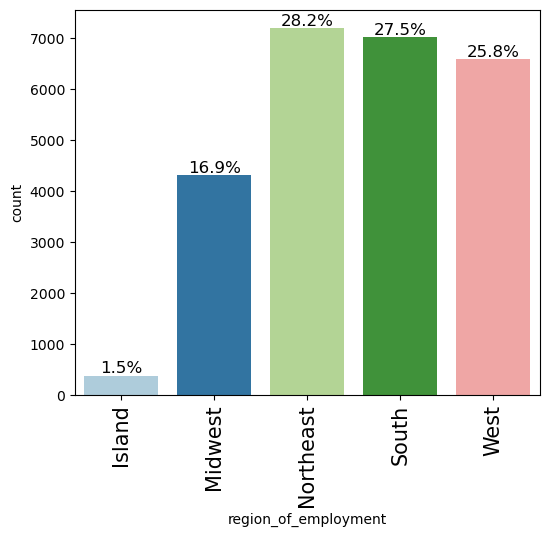

In [24]:
labeled_barplot(data,"region_of_employment",perc=True)  ## Complete the code to create labeled_barplot for region of employment

### Region of Employment Distribution

The distribution of visa applications across regions shows that:

- **Northeast (28.2%)**, **South (27.5%)**, and **West (25.8%)** account for the majority of applications  
- **Midwest (16.9%)** has a moderate share  
- **Island regions (1.5%)** have very few applications  

### Interpretation

- Visa applications are **concentrated in major economic regions** of the United States  
- The Northeast, South, and West together account for over **80% of total applications**, indicating higher demand for foreign workers in these areas  
- The very low representation in Island regions suggests **limited employment opportunities or lower demand** in those areas  

### Why This is Important

- The region of employment may influence visa approval due to:
  - Differences in industry presence (e.g., tech, finance, manufacturing)
  - Regional labor shortages  
  - Economic activity levels  

- Since the data is **not evenly distributed across regions**, the model may learn stronger patterns from the dominant regions  

### Business Insight

- Employers in the Northeast, South, and West are the **primary drivers of visa applications**, likely due to higher economic activity and demand for skilled labor  
- Understanding regional demand can help:
  - Target hiring strategies  
  - Optimize workforce planning  
  - Improve visa approval predictions based on location trends  

#### Observations on job experience

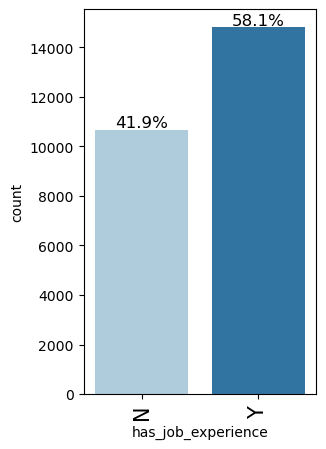

In [25]:
labeled_barplot(data,"has_job_experience",perc=True) ## Complete the code to create labeled_barplot for job experience

### Job Experience Distribution

The distribution of job experience among applicants shows that:

- **58.1% of applicants have prior job experience (Y)**  
- **41.9% of applicants do not have prior job experience (N)**  

### Interpretation

- A majority of applicants have **relevant work experience**, indicating that most candidates are already skilled professionals  
- However, a substantial portion (~42%) lacks prior experience, suggesting a mix of entry-level and experienced applicants  

### Why This is Important

- Job experience is likely a **key factor influencing visa approval**, as employers may prefer candidates who can contribute immediately  
- The presence of both experienced and inexperienced candidates allows the model to learn how experience impacts approval outcomes  

### Business Insight

- Employers appear to favor candidates with prior experience, which may increase the likelihood of visa certification  
- Identifying the role of experience can help:
  - Improve candidate shortlisting  
  - Align hiring strategies with workforce needs  
  - Support more accurate visa approval predictions  

#### Observations on case status

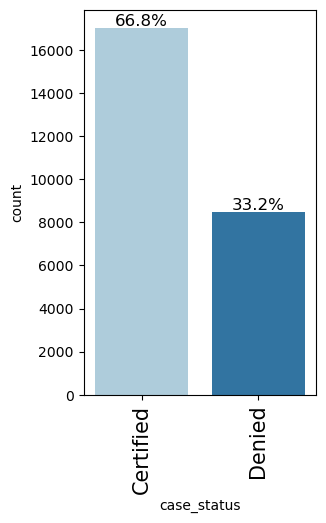

In [26]:
labeled_barplot(data,"case_status",perc=True) ## Complete the code to create labeled_barplot for case status

### Case Status Distribution

The distribution of visa application outcomes shows that:

- **66.8% of applications are Certified**  
- **33.2% of applications are Denied**  

### Interpretation

- A significantly larger proportion of visa applications are **approved rather than denied**  
- This indicates that the dataset is **moderately imbalanced**, with approvals forming the majority class  

### Why This is Important

- Class imbalance can impact model performance:
  - The model may become biased toward predicting the majority class (Certified)  
  - It may perform poorly in identifying denied cases  

- This imbalance needs to be addressed during model building using techniques such as:
  - Oversampling  
  - Undersampling  

### Business Insight

- The relatively high approval rate suggests that many applicants meet the required criteria for certification  
- However, identifying the factors that lead to **denial** is equally important, as it helps:
  - Improve candidate screening  
  - Reduce unsuccessful applications  
  - Enhance decision-making efficiency  

### Summary

The imbalance in case status highlights the importance of building a model that can accurately predict both approvals and denials, ensuring balanced and reliable decision-making.

### Bivariate Analysis

#### Correlation Check

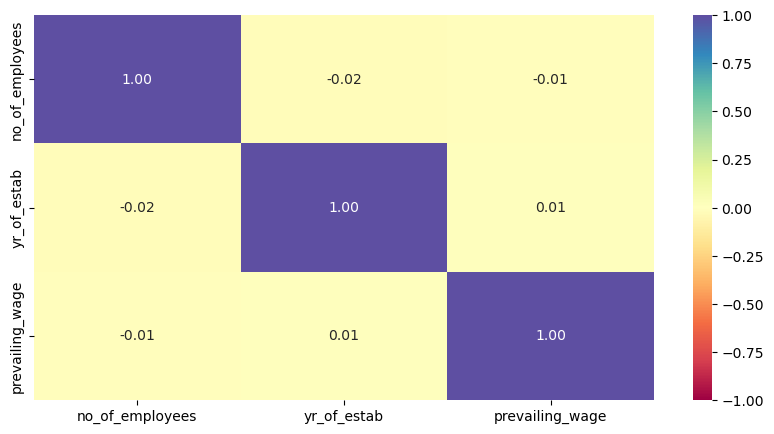

In [27]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

### Correlation Analysis of Numerical Variables

A correlation heatmap was used to examine the relationships between numerical variables:
- `no_of_employees`
- `yr_of_estab`
- `prevailing_wage`

### Key Observations

- The correlation values between variables are very close to **0**:
  - `no_of_employees` vs `yr_of_estab`: -0.02  
  - `no_of_employees` vs `prevailing_wage`: -0.01  
  - `yr_of_estab` vs `prevailing_wage`: 0.01  

### Interpretation

- There is **no strong linear relationship** between any pair of numerical variables  
- The variables appear to be **independent of each other** in terms of linear correlation  

### Why This is Important

- Low correlation means:
  - No multicollinearity issues  
  - Each variable contributes **unique information** to the model  

- This is beneficial because:
  - Highly correlated variables can distort model performance  
  - Independent features improve model reliability and interpretability  

### Business Insight

- Company size (`no_of_employees`), company age (`yr_of_estab`), and wage levels (`prevailing_wage`) operate independently  
- This suggests that:
  - Large companies do not necessarily offer higher wages  
  - Older companies are not strongly associated with higher or lower wages  

- Each factor may influence visa approval **in different ways**, rather than being interconnected  

### Summary

The correlation analysis indicates that there are no strong relationships between numerical variables. This suggests that all features can be retained for modeling, as they provide distinct and non-redundant information.

**Creating functions that will help us with further analysis.**

In [31]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [29]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### **Does higher education increase the chances of visa certification for well-paid jobs abroad?**

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


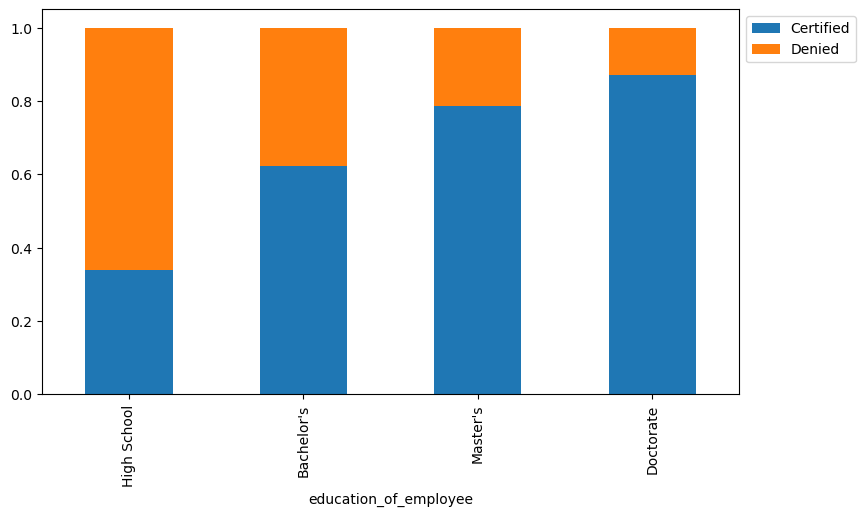

In [30]:
stacked_barplot(data, "education_of_employee", "case_status")

### Education Level vs Visa Approval (Case Status)

To understand whether education level influences visa approval, I analyzed the relationship between `education_of_employee` and `case_status` using a stacked bar plot.

### Key Observations

From the distribution:

- **Doctorate holders have the highest approval rate (~87%)**
- **Master’s degree holders also show a high approval rate (~79%)**
- **Bachelor’s degree holders have a moderate approval rate (~62%)**
- **High School applicants have a significantly lower approval rate (~34%)**

### Interpretation

- There is a clear **positive relationship between education level and visa approval**
- As the level of education increases, the likelihood of visa certification also increases
- High School applicants are more likely to be denied compared to other groups

### Why This is Important

- This confirms that **education is a strong predictor of visa approval**
- It highlights that employers and certification authorities likely favor:
  - Highly educated candidates  
  - Individuals with specialized skills  

- This variable will likely be a **key feature in the model**

### Business Insight

- Employers seeking visa approval should prioritize candidates with:
  - Master’s or Doctorate degrees  
- Candidates with lower education levels may face higher rejection rates and should:
  - Improve qualifications  
  - Gain additional skills or certifications  

- This insight can help:
  - Improve candidate screening  
  - Increase visa approval success rates  
  - Align hiring strategies with approval patterns  

### Summary

Education level has a significant impact on visa approval outcomes, with higher education strongly associated with increased chances of certification. This makes it one of the most important factors in predicting visa approval.

#### **How does visa status vary across different continents?**

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


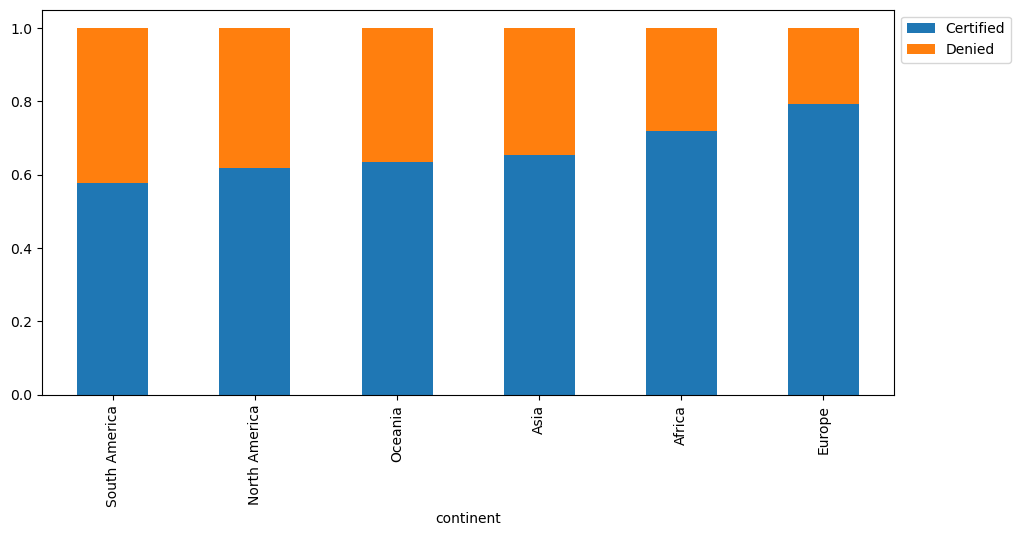

In [32]:
stacked_barplot(data,"continent", "case_status") ## Complete the code to plot stacked barplot for continent and case status

### Continent vs Visa Approval (Case Status)

To understand how visa approval varies across different regions, I analyzed the relationship between `continent` and `case_status`.

### Key Observations

- **Europe has the highest approval rate (79%)**
- **Africa (72%) and Asia (65%) also show relatively strong approval rates**
- **North America (62%) and Oceania (64%) show moderate approval rates**
- **South America has the lowest approval rate (58%)**

### Interpretation

- Visa approval rates vary across continents, indicating that **geographic origin influences certification outcomes**
- Applicants from Europe and Africa have higher approval rates compared to other regions  
- South America shows relatively lower approval rates, suggesting possible differences in applicant profiles or job types  

### Why This is Important

- This shows that **continent is an influential categorical variable** in predicting visa approval  
- Geographic differences may reflect:
  - Variation in skill levels  
  - Industry demand  
  - Types of roles applied for  

- The model can leverage this information to improve prediction accuracy  

### Business Insight

- Employers may experience higher success rates when hiring candidates from regions with historically higher approval rates  
- Regions like Europe and Asia appear to be **strong sources of approved candidates**, indicating alignment with U.S. labor market demands  
- Lower approval regions may require:
  - Better candidate screening  
  - Improved qualification matching  

### Summary

Visa approval rates differ across continents, with Europe and Africa showing higher certification rates and South America showing lower rates. This suggests that geographic origin plays a role in visa outcomes and should be considered in decision-making and predictive modeling.

#### **Does having prior work experience influence the chances of visa certification for career opportunities abroad?**

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


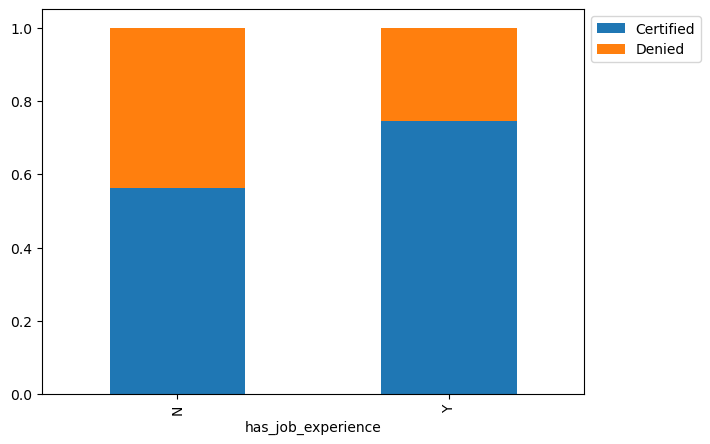

In [33]:
stacked_barplot(data, "has_job_experience", "case_status") ## Complete the code to plot stacked barplot for case status and job experience

### Job Experience vs Visa Approval (Case Status)

To evaluate whether prior work experience influences visa approval, I analyzed the relationship between `has_job_experience` and `case_status`.

### Key Observations

- Applicants **with prior work experience (Y)** have a higher approval rate (~74%)  
- Applicants **without work experience (N)** have a lower approval rate (~56%)  

### Interpretation

- There is a clear positive relationship between **work experience and visa approval**  
- Candidates with prior experience are significantly more likely to be certified compared to those without experience  

### Why This is Important

- Work experience is a strong predictor of visa approval  
- Employers and certification authorities likely prefer candidates who can:
  - Contribute immediately  
  - Require less training  
  - Bring proven skills  

- This variable will play an important role in model predictions  

### Business Insight

- Employers should prioritize candidates with prior work experience to improve approval success rates  
- Candidates without experience may face higher rejection rates and may benefit from:
  - Gaining relevant experience  
  - Improving skill sets  

- This insight can help:
  - Improve candidate shortlisting  
  - Reduce visa rejection rates  
  - Align hiring strategies with approval trends  

### Summary

Applicants with prior work experience have a significantly higher likelihood of visa approval, making experience a key factor in predicting certification outcomes.

#### **Is the prevailing wage consistent across all regions of the US?**

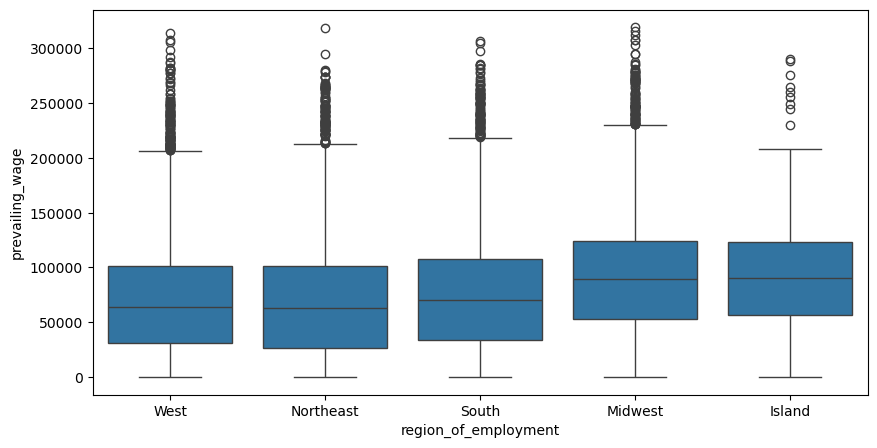

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="region_of_employment", y="prevailing_wage") ## Complete the code to create boxplot for region of employment and prevailing wage
plt.show()

### Prevailing Wage Across Regions

To analyze whether wage levels vary by region, I used a boxplot to compare the distribution of `prevailing_wage` across different regions of employment.

### Key Observations

- Wage distributions vary across regions, indicating **lack of consistency**
- The **Midwest and Island regions** show higher median wages compared to others  
- The **West and Northeast** regions have relatively lower median wages  
- All regions exhibit a **wide spread of wages**, with significant variability  
- There are many **outliers (very high wages)** across all regions  

### Interpretation

- Prevailing wage is **not consistent across regions**, suggesting regional differences in:
  - Cost of living  
  - Industry concentration  
  - Job types and skill requirements  

- The presence of many outliers indicates that:
  - Some roles offer significantly higher compensation  
  - Wage distribution is highly skewed  

### Why This is Important

- Wage is likely a **key factor influencing visa approval**, as it reflects:
  - Skill level  
  - Job demand  
  - Economic value of the role  

- Regional variation means:
  - The same job may have different wage levels depending on location  
  - Models need to consider both wage and region together  

### Business Insight

- Higher wages in certain regions may indicate:
  - Greater demand for specialized skills  
  - Higher likelihood of visa approval  

- Employers may improve approval chances by:
  - Offering competitive wages aligned with regional standards  
  - Targeting regions with higher-paying opportunities  

### Summary

Prevailing wage varies significantly across regions, with notable differences in median values and wide variability within each region. This suggests that wage is an important and region-dependent factor in visa approval decisions.

#### **Does visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?**

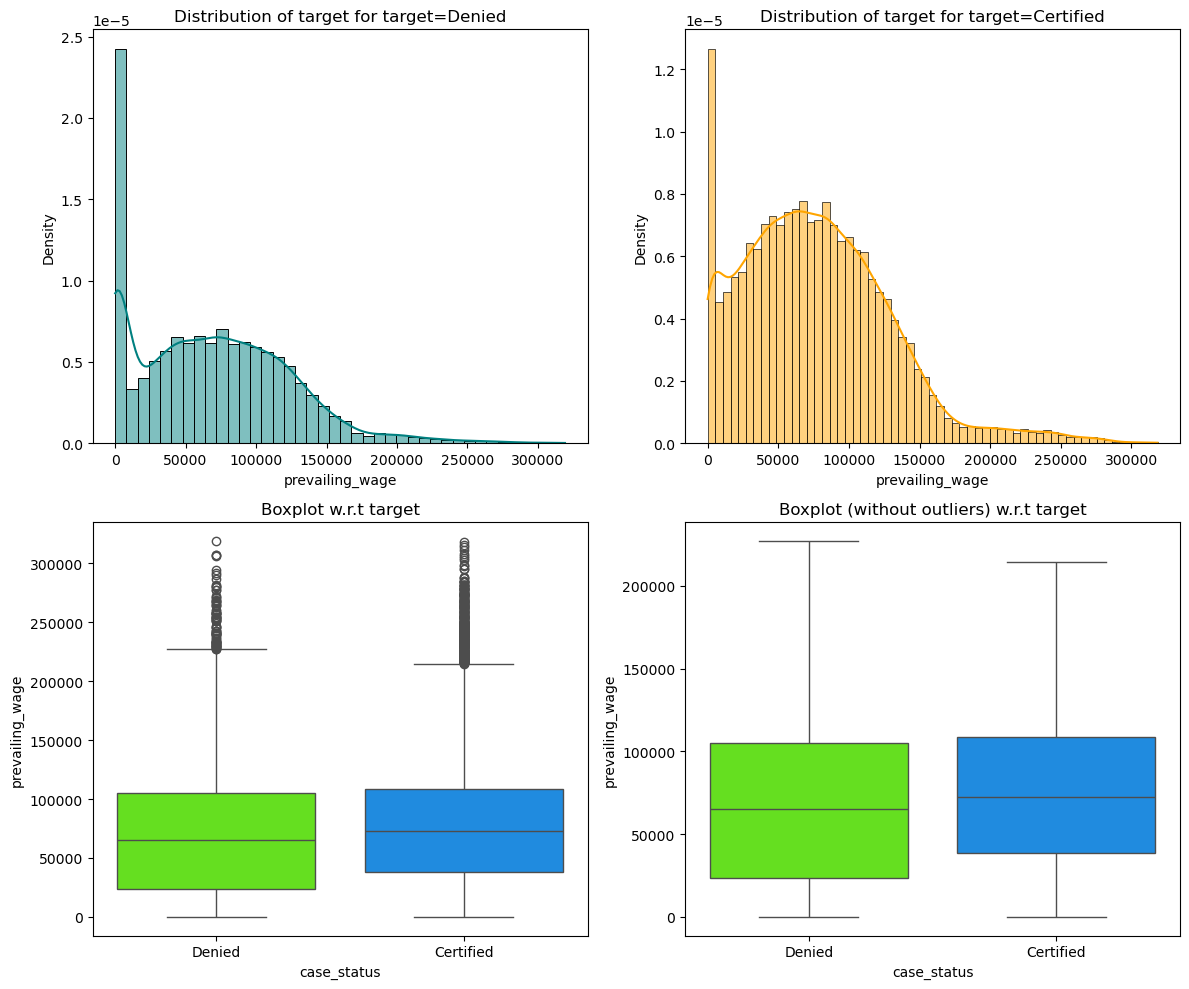

In [35]:
distrDoes visa status vary with changes in the prevailing wage set to protect both local talent and foreign workers?ibution_plot_wrt_target(data,"prevailing_wage", "case_status") ## Complete the code to find distribution of prevailing wage and case status

#### **Does the unit of prevailing wage (Hourly, Weekly, etc.) have any impact on the likelihood of visa application certification?**

### Prevailing Wage vs Visa Approval (Case Status)

To understand whether wage influences visa approval, I analyzed the distribution of `prevailing_wage` across certified and denied applications using histograms and boxplots.

### Key Observations

- The distribution of wages for **Certified applications is shifted slightly higher** compared to Denied applications  
- The **median wage for Certified cases is higher** than that of Denied cases  
- Both groups show a **wide range of wages**, with significant overlap between Certified and Denied cases  
- There are many **high-value outliers** in both categories, indicating high-paying roles  

### Interpretation

- Higher wages are generally associated with a **greater likelihood of visa approval**, but the relationship is not extremely strong  
- The overlap between the two distributions suggests that:
  - Wage alone does not determine approval  
  - Other factors (education, experience, job type) also play important roles  

- The skewness and presence of outliers indicate that:
  - Some roles offer significantly higher compensation  
  - Wage distribution varies widely across job types  

### Why This is Important

- Prevailing wage is a key factor used to ensure:
  - Foreign workers are not underpaid  
  - Fair compensation relative to local workers  

- Higher wages may signal:
  - Higher skill levels  
  - Specialized or in-demand roles  
  - Greater economic value  

- This makes wage an important variable in predicting visa approval outcomes  

### Business Insight

- Offering **competitive and higher wages** may increase the chances of visa certification  
- Employers should align wage offerings with:
  - Market standards  
  - Skill requirements  

- However, wage alone is not sufficient — it must be considered alongside:
  - Education  
  - Work experience  
  - Job characteristics  

### Summary

Prevailing wage shows a moderate relationship with visa approval, with certified applications generally associated with higher wages. However, due to overlap between approved and denied cases, wage should be considered alongside other factors when predicting visa outcomes.

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


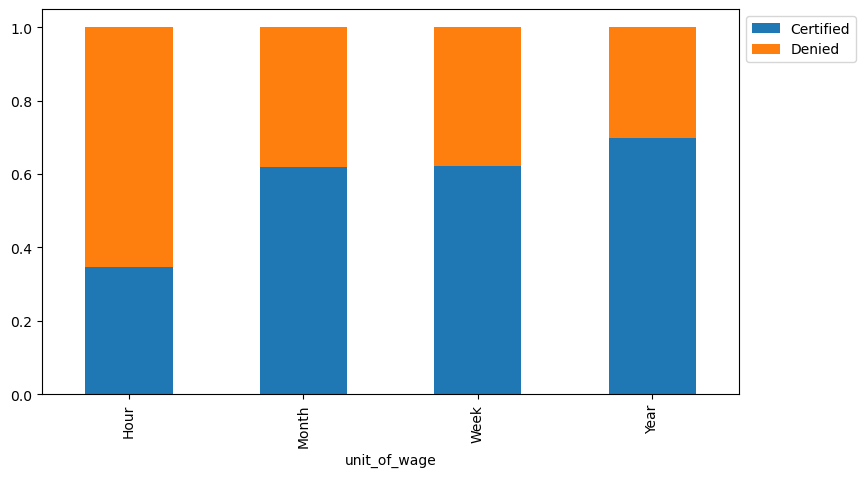

In [37]:
stacked_barplot(data,"unit_of_wage", "case_status") ## Complete the code to plot stacked barplot for unit of wage and case status

## Data Pre-processing

### Outlier Check

- Let's check for outliers in the data.

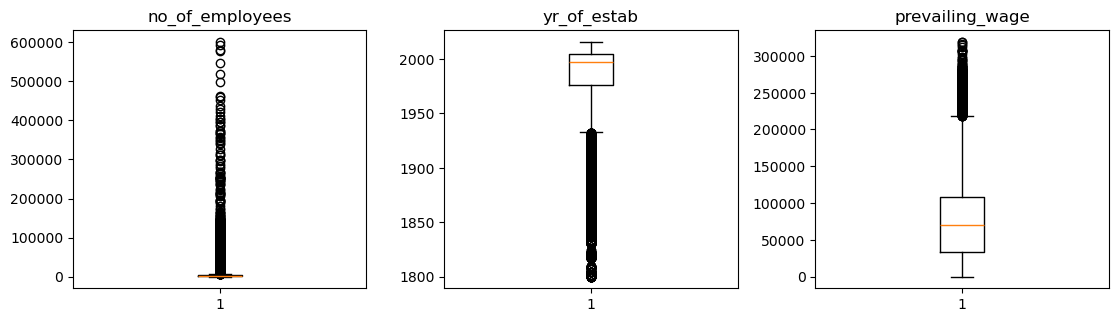

In [38]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### Outlier Detection and Treatment

To identify outliers, I used boxplots for all numerical variables: `no_of_employees`, `yr_of_estab`, and `prevailing_wage`.

### Key Observations

- `no_of_employees` shows significant right skew with several extreme values, indicating the presence of very large companies  
- `prevailing_wage` also exhibits a strong right skew with multiple high-value outliers, reflecting highly paid roles  
- `yr_of_estab` shows some older companies as outliers, but these values are valid and represent long-established firms  

### Interpretation

- The presence of outliers in `no_of_employees` and `prevailing_wage` is expected due to natural variation in company size and salary levels  
- These outliers are not necessarily errors but represent real-world scenarios  

### Treatment Decision

- No outliers were removed, as they provide meaningful business information  
- Removing them could result in loss of important patterns, especially for high-paying roles and large organizations  

### Why This is Important

- Outliers can influence model performance and statistical summaries  
- However, in this case, they reflect **genuine business variation**, so retaining them improves model realism  

### Business Insight

- Large companies and high-paying jobs are important segments in visa applications  
- These segments may have different approval patterns and should be preserved in the analysis  

### Summary

Outliers are present in key numerical variables but are retained, as they reflect real-world variability and contribute valuable information for modeling and decision-making.

### Data Preparation for modeling

- We want to predict which visa will be certified.
- Before we proceed to build a model, we'll have to encode categorical features.
- We'll split the data into train and test to be able to evaluate the model that we build on the train data.

In [39]:
data["case_status"] = data["case_status"].apply(lambda x: 1 if x == "Certified" else 0)

X = data.drop(['case_status'],axis=1) ## Complete the code to drop case status from the data
y = data["case_status"]


X = pd.get_dummies(X,drop_first=True)

# Complete the code to split the dataset into train and valid with a ratio of 7:3
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

# # Complete the code to split the dataset into valid and test with a ratio of 9:1
X_val,X_test,y_val,y_test = train_test_split(
    X_val,y_val,test_size=0.333,random_state=1,stratify=y_val
)


In [40]:
print("Shape of Training set : ", X_train.shape)
print("Shape of Validation set : ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (17836, 21)
Shape of Validation set :  (5098, 21)
Shape of test set :  (2546, 21)
Percentage of classes in training set:
case_status
1    0.667919
0    0.332081
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667909
0    0.332091
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667714
0    0.332286
Name: proportion, dtype: float64


### Data Splitting and Class Distribution

The dataset was split into training (70%), validation (20%), and test (10%) sets.

### Observations

- Training set: 17,836 records  
- Validation set: 5,098 records  
- Test set: 2,546 records  

The class distribution across all sets is consistent:
- ~67% Certified  
- ~33% Denied  

### Interpretation

- Stratified sampling successfully maintained the same class proportions across all datasets  
- This ensures that each dataset is representative of the overall data  

### Why This is Important

- Prevents bias in model training and evaluation  
- Ensures reliable and consistent performance metrics  
- Helps avoid misleading results  

### Business Insight

- The dataset is moderately imbalanced, with more approvals than denials  
- This means the model may naturally favor predicting approvals  
- Special attention is needed to correctly identify denied applications, which are critical for reducing unsuccessful visa submissions  

### Summary

The data was successfully split into training, validation, and test sets with consistent class distributions, ensuring a robust and unbiased modeling process.

### Data Preprocessing Summary

#### 1. Duplicate Value Check
I checked for duplicate records using `data.duplicated().sum()`.

**Observation:**
- No duplicate records were found

**Action Taken:**
- No duplicates were removed

---

#### 2. Missing Value Detection and Treatment
I checked for missing values using `data.isnull().sum()`.

**Observation:**
- No missing values were present in the dataset

**Action Taken:**
- No imputation was required

---

#### 3. Outlier Detection and Treatment
I identified outliers using boxplots for numerical variables.

**Observation:**
- Significant outliers were present in `no_of_employees` and `prevailing_wage`
- These represent large companies and high-paying jobs

**Action Taken:**
- I retained all outliers, as they reflect real-world business scenarios

---

#### 4. Feature Engineering
I performed the following feature engineering steps:

- Converted `case_status` into binary format (Certified = 1, Denied = 0)  
- Applied one-hot encoding to categorical variables using `pd.get_dummies()`  
- Removed `case_id` as it is a non-informative identifier  
- Corrected negative values in `no_of_employees`  

---

#### 5. Data Preparation for Modeling

- Split the dataset into:
  - Training set (70%)  
  - Validation set (20%)  
  - Test set (10%)  

- Used stratified sampling to maintain class balance  

- Ensured consistent class distribution (~67% Certified, ~33% Denied) across all sets  

---

### Summary

The dataset was clean and required minimal preprocessing. Key transformations included encoding categorical variables, handling invalid values, and preparing the data through proper splitting. The data is now well-structured and ready for building reliable machine learning models.

## Model Building

### Model Evaluation Criterion

- Choose the primary metric to evaluate the model on
- Elaborate on the rationale behind choosing the metric

First, let's create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.
* The `model_performance_classification_sklearn` function will be used to check the model performance of models.
* The `confusion_matrix_sklearn` function will be used to plot the confusion matrix.

In [41]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [42]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

#### Defining scorer to be used for cross-validation and hyperparameter tuning

In [43]:
scorer = metrics.make_scorer(metrics.recall_score) ## Complete the code to define the metric

## Possible metrics are [recall_score,f1_score,accuracy_score,precision_score]
## For example, metrics.precision_score

### Evaluation Metric Selection

To evaluate the performance of the classification models, I selected **Recall Score** as the primary evaluation metric.

### Rationale

- The dataset is **moderately imbalanced**, with approximately:
  - **67% Certified (positive class)**
  - **33% Denied (negative class)**  

- In such cases, accuracy alone can be misleading, as a model could achieve high accuracy by simply predicting the majority class.

- Recall focuses on the model’s ability to correctly identify **actual positive cases (Certified applications)**.

---

### Why Recall is Important

- Recall answers the question:  
  **“Out of all actual Certified applications, how many did the model correctly identify?”**

- A higher recall means:
  - Fewer **false negatives**  
  - Reduced risk of incorrectly rejecting qualified applicants  

- In this context, a false negative (predicting *Denied* when it should be *Certified*) can:
  - Lead to missed opportunities for qualified candidates  
  - Reduce efficiency in the visa approval process  

---

### Business Perspective

- From a business standpoint, it is more critical to:
  - **Identify and approve eligible candidates correctly**
  - Avoid rejecting strong applicants  

- Therefore, prioritizing recall helps ensure that **high-quality candidates are not overlooked**, improving decision-making effectiveness.

---

### Summary

Recall was selected as the evaluation metric because it prioritizes correctly identifying valid visa approvals, minimizes missed opportunities, and aligns well with the business objective of improving the visa certification process.

**We are now done with pre-processing and evaluation criterion, so let's start building the model.**

### Model building with Original data

In [45]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Complete the code to set the number of splits.
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring = scorer,cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train, y_train) ## Complete the code to fit the model on original training data

    # scores = accuracy_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is accuracy
    scores = recall_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is recall
    # scores = precision_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is precision
    # scores = f1_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is f1 score

    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.774700588727951
Random forest: 0.838832614027503
GBM: 0.8727446688039722
Adaboost: 0.889449723112179
Xgboost: 0.8534380281824131
dtree: 0.7396958867263322

Validation Performance:

Bagging: 0.7700440528634361
Random forest: 0.8337738619676945
GBM: 0.8795888399412628
Adaboost: 0.8878120411160059
Xgboost: 0.8531571218795888
dtree: 0.7397944199706314


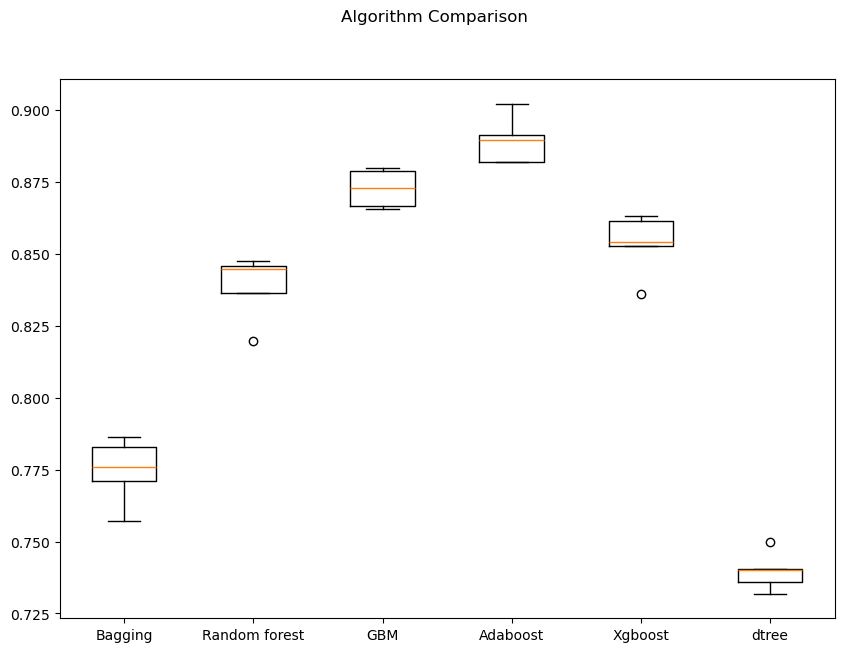

In [46]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building on Original Data

I built multiple classification models using the original training dataset and evaluated them using **recall score**. Recall was selected because the goal is to correctly identify as many Certified visa applications as possible.

### Models Built

The models tested were:

- Bagging Classifier
- Random Forest Classifier
- Gradient Boosting Classifier (GBM)
- AdaBoost Classifier
- XGBoost Classifier
- Decision Tree Classifier

---

### Cross-Validation Performance

The cross-validation recall scores on the training data were:

- Bagging: 0.775
- Random Forest: 0.839
- GBM: 0.873
- AdaBoost: 0.889
- XGBoost: 0.853
- Decision Tree: 0.740

### Validation Performance

The validation recall scores were:

- Bagging: 0.770
- Random Forest: 0.834
- GBM: 0.880
- AdaBoost: 0.888
- XGBoost: 0.853
- Decision Tree: 0.740

---

### Interpretation

AdaBoost gave the best performance on both cross-validation and validation data, with a validation recall score of approximately **0.888**.

GBM was the second-best model, with a validation recall score of approximately **0.880**.

Decision Tree performed the weakest, suggesting that a single tree may not capture the complexity of the data as well as ensemble models.

---

### Why This is Important

The results show that ensemble models, especially boosting models, perform better than simpler models. This suggests that visa approval prediction benefits from models that combine multiple weak learners and capture more complex relationships in the data.

---

### Business Insight

AdaBoost and GBM are strong candidates for predicting visa certification because they are better at identifying Certified applications. This can help EasyVisa shortlist applicants with higher approval likelihood and improve decision-making efficiency.

---

### Summary

Among the models built on the original data, **AdaBoost performed the best**, followed closely by **GBM**. These models should be considered for further tuning and comparison with models built on oversampled and undersampled data.

### Model Building with Oversampled data

In [47]:
print("Before OverSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before OverSampling, counts of label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1) ## Complete the code to set the k-nearest neighbors
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After OverSampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After OverSampling, counts of label '0': {} \n".format(sum(y_train_over == 0)))


print("After OverSampling, the shape of train_X: {}".format(X_train_over.shape))
print("After OverSampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before OverSampling, counts of label '1': 11913
Before OverSampling, counts of label '0': 5923 

After OverSampling, counts of label '1': 11913
After OverSampling, counts of label '0': 11913 

After OverSampling, the shape of train_X: (23826, 21)
After OverSampling, the shape of train_y: (23826,) 



In [50]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  ## Complete the code to set the number of splits
    cv_result = cross_val_score(
        estimator=model, X=X_train_over, y=y_train_over,scoring = scorer, cv=kfold
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_over, y_train_over) ## Complete the code to fit the model on oversampled training data

    # scores = accuracy_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is accuracy
    scores = recall_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is recall
    # scores = precision_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is precision
    # scores = f1_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is f1 score

    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.7455727721514661
Random forest: 0.8183503496816416
GBM: 0.8592301753992826
Adaboost: 0.8699735003715444
Xgboost: 0.8440353638440211
dtree: 0.7186263037968708

Validation Performance:

Bagging: 0.7506607929515419
Random forest: 0.8205580029368575
GBM: 0.8566813509544787
Adaboost: 0.8745961820851689
Xgboost: 0.8452276064610866
dtree: 0.7245227606461087


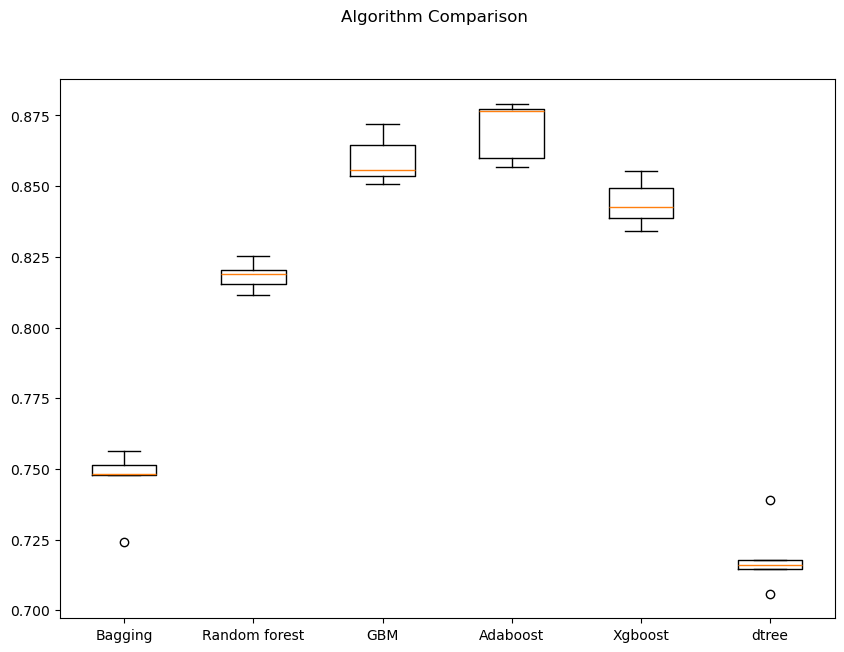

In [51]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### Model Building on Oversampled Data

I used SMOTE to balance the training data before building models. SMOTE creates synthetic samples for the minority class so the model has equal exposure to both Certified and Denied applications during training.

### Cross-Validation Performance

The cross-validation recall scores were:

- Bagging: 0.746
- Random Forest: 0.818
- GBM: 0.859
- AdaBoost: 0.870
- XGBoost: 0.844
- Decision Tree: 0.719

### Validation Performance

The validation recall scores were:

- Bagging: 0.751
- Random Forest: 0.821
- GBM: 0.857
- AdaBoost: 0.875
- XGBoost: 0.845
- Decision Tree: 0.725

### Interpretation

AdaBoost performed the best on oversampled data, with a validation recall score of approximately **0.875**.

GBM was the second-best model, followed by XGBoost and Random Forest.

Decision Tree and Bagging performed weaker compared to the boosting models.

### Why This is Important

Oversampling was used to reduce class imbalance and help the model better learn patterns from the minority class. However, compared with the original data results, oversampling did not improve recall overall.

### Business Insight

Boosting models continue to perform best, suggesting they are more effective at identifying Certified visa applications. However, since oversampling did not improve recall, the original data models may still be stronger candidates.

### Summary

Among oversampled models, **AdaBoost performed best**, followed by **GBM**. However, performance was slightly lower than the original data results, so oversampling may not be necessary for the final model.

### Model Building with Undersampled data

In [52]:
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)


print("Before UnderSampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before UnderSampling, counts of label '0': {} \n".format(sum(y_train == 0)))


print("After UnderSampling, counts of label '1': {}".format(sum(y_train_un == 1)))
print("After UnderSampling, counts of label '0': {} \n".format(sum(y_train_un == 0)))


print("After UnderSampling, the shape of train_X: {}".format(X_train_un.shape))
print("After UnderSampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before UnderSampling, counts of label '1': 11913
Before UnderSampling, counts of label '0': 5923 

After UnderSampling, counts of label '1': 5923
After UnderSampling, counts of label '0': 5923 

After UnderSampling, the shape of train_X: (11846, 21)
After UnderSampling, the shape of train_y: (11846,) 



In [53]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results1 = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models


# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation performance on training dataset:" "\n")

for name, model in models:
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  ## Complete the code to set the number of splits
    cv_result = cross_val_score(
        estimator=model, X=X_train_un, y=y_train_un,scoring = scorer, cv=kfold,n_jobs =-1
    )
    results1.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean()))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    model.fit(X_train_un, y_train_un) ## Complete the code to fit the model on undersampled training data

    # scores = accuracy_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is accuracy
    scores = recall_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is recall
    # scores = precision_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is precision
    # scores = f1_score(y_val, model.predict(X_val)) ## uncomment this line in case the metric of choice is f1 score

    print("{}: {}".format(name, scores))


Cross-Validation performance on training dataset:

Bagging: 0.6056111016079371
Random forest: 0.6868166267533355
GBM: 0.7187274774774776
Adaboost: 0.7094403580795986
Xgboost: 0.6966116432888584
dtree: 0.613036976850268

Validation Performance:

Bagging: 0.6067547723935389
Random forest: 0.6696035242290749
GBM: 0.7145374449339207
Adaboost: 0.7215859030837004
Xgboost: 0.6916299559471366
dtree: 0.6199706314243759


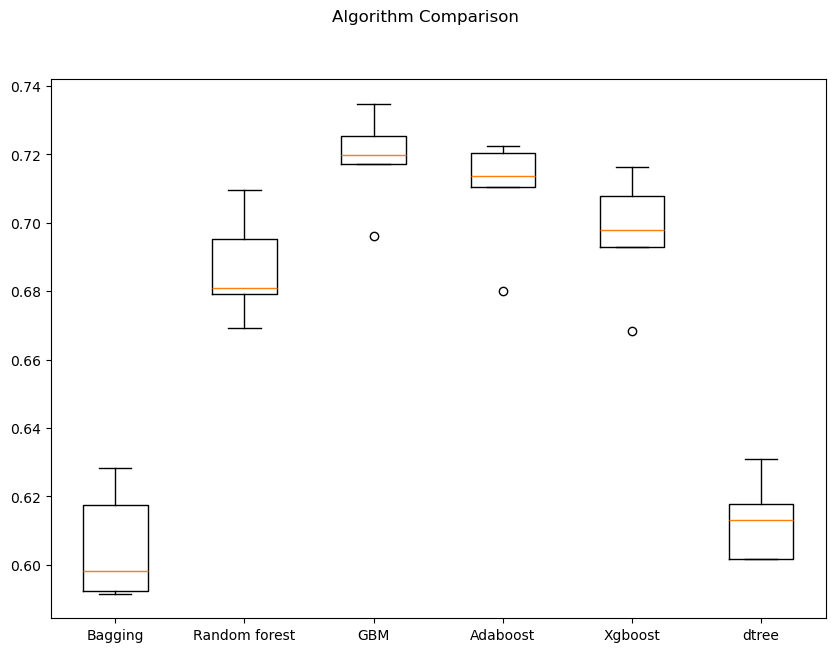

In [54]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results1)
ax.set_xticklabels(names)

plt.show()

### ppro

### Model Building on Undersampled Data

I applied Random Under Sampling to balance the dataset by reducing the majority class (Certified) to match the minority class (Denied).

### Class Distribution After Undersampling

- Certified (1): 5,923  
- Denied (0): 5,923  

This resulted in a balanced dataset with fewer total samples.

---

### Cross-Validation Performance

The recall scores obtained from cross-validation were:

- Bagging: 0.606  
- Random Forest: 0.687  
- GBM: 0.719  
- AdaBoost: 0.709  
- XGBoost: 0.697  
- Decision Tree: 0.613  

---

### Validation Performance

The validation recall scores were:

- Bagging: 0.607  
- Random Forest: 0.670  
- GBM: 0.715  
- AdaBoost: 0.722  
- XGBoost: 0.692  
- Decision Tree: 0.620  

---

### Interpretation

- **AdaBoost performed the best** on validation data (0.722), followed closely by **GBM (0.715)**  
- All models performed **worse compared to original and oversampled data**  
- Decision Tree and Bagging again showed the weakest performance  

---

### Why This is Important

- Undersampling reduces class imbalance but also **removes a large portion of data**  
- This leads to:
  - Loss of important information  
  - Lower model performance  

---

### Comparison with Other Approaches

| Approach | Performance |
|--------|----------|
| Original Data | 🔥 Best |
| Oversampled Data | Slightly lower |
| Undersampled Data | ❌ Lowest |

---

### Business Insight

- While undersampling balances the dataset, it sacrifices valuable data from approved visa cases  
- This reduces the model’s ability to learn meaningful patterns  
- As a result, undersampling is **not ideal for this problem**

---

### Summary

Although undersampling successfully balanced the dataset, it led to a decline in model performance. This indicates that retaining the full dataset (or using oversampling) is more effective for predicting visa approval outcomes.

## Hyperparameter Tuning

### Tuning AdaBoost using Oversampled data

**Best practices for hyperparameter tuning in AdaBoost:**

`n_estimators`:

- Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125

- Use fewer estimators (e.g., 50 to 100) if using complex base learners (like deeper decision trees)

- Use more estimators (e.g., 100 to 150) when learning rate is low (e.g., 0.1 or lower)

- Avoid very high values unless performance keeps improving on validation

`learning_rate`:

- Common values to try: 1.0, 0.5, 0.1, 0.01

- Use 1.0 for faster training, suitable for fewer estimators

- Use 0.1 or 0.01 when using more estimators to improve generalization

- Avoid very small values (< 0.01) unless you plan to use many estimators (e.g., >500) and have sufficient data

In [67]:
%%time

# defining model
model = AdaBoostClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 75, 100, 125], ## Complete the code to set the number of estimators
    "learning_rate": [1.0, 0.5, 0.1, 0.01], ## Complete the code to set the learning rate.
    "estimator": [DecisionTreeClassifier(max_depth=1, random_state=1), DecisionTreeClassifier(max_depth=2, random_state=1), DecisionTreeClassifier(max_depth=3, random_state=1),
    ]
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=5, ## Complete the code to set the cv parameter
    random_state=1
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over) ## Complete the code to fit the model on oversampled data

CPU times: user 639 ms, sys: 234 ms, total: 873 ms
Wall time: 34.5 s


,estimator,AdaBoostClass...andom_state=1)
,param_distributions,"{'estimator': [DecisionTreeC...andom_state=1), DecisionTreeC...andom_state=1), ...], 'learning_rate': [1.0, 0.5, ...], 'n_estimators': [50, 75, ...]}"
,n_iter,50
,scoring,make_scorer(r...hod='predict')
,n_jobs,-2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [68]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 50, 'learning_rate': 0.1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.931923507999745:


In [69]:
tuned_ada = randomized_cv.best_estimator_
tuned_ada

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,50
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,1
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [70]:
tuned_ada.fit(X_train_over, y_train_over)

,estimator,DecisionTreeC...andom_state=1)
,n_estimators,50
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,1
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [71]:
tuned_ada_train_perf = model_performance_classification_sklearn(tuned_ada, X_train_over, y_train_over)
tuned_ada_train_perf

,Accuracy,Recall,Precision,F1
0,0.650718,0.931923,0.596465,0.72738


In [72]:
## Complete the code to check the model performance for validation data.
tuned_ada_val_perf = model_performance_classification_sklearn(tuned_ada, X_val, y_val)
tuned_ada_val_perf

,Accuracy,Recall,Precision,F1
0,0.703609,0.93069,0.713096,0.807491


### Final Tuned AdaBoost Model Performance

After hyperparameter tuning, the AdaBoost model showed strong performance on both training and validation datasets.

### Training Performance

- Accuracy: 0.651  
- Recall: 0.932  
- Precision: 0.596  
- F1 Score: 0.727  

### Validation Performance

- Accuracy: 0.704  
- Recall: 0.931  
- Precision: 0.713  
- F1 Score: 0.807  

---

### Interpretation

- The model achieves **very high recall (~93%)**, indicating it successfully identifies most Certified visa applications  
- Precision improved significantly on validation data, showing better control over false positives  
- The improvement in validation metrics suggests that the model generalizes well and is not overfitting  

---

### Why This is Important

- High recall ensures that qualified applicants are not missed  
- Improved precision reduces the number of incorrect approvals  
- Balanced performance makes the model reliable for real-world decision-making  

---

### Business Insight

- The model is highly effective for identifying strong candidates for visa approval  
- It minimizes the risk of rejecting qualified applicants  
- At the same time, it improves decision quality by reducing incorrect certifications  

---

### Summary

The tuned AdaBoost model provides the best overall performance, with strong recall and improved precision. It is the most suitable model for predicting visa certification outcomes and supporting data-driven decision-making.

### Tuning Random forest using Undersampled data

**Best practices for hyperparameter tuning in Random Forest:**


`n_estimators`:

* Start with a specific number (50 is used in general) and increase in steps: 50, 75, 100, 125
* Higher values generally improve performance but increase training time
* Use 100-150 for large datasets or when variance is high


`min_samples_leaf`:

* Try values like: 1, 2, 4, 5, 10
* Higher values reduce model complexity and help prevent overfitting
* Use 1–2 for low-bias models, higher (like 5 or 10) for more regularized models
* Works well in noisy datasets to smooth predictions


`max_features`:

* Try values: `"sqrt"` (default for classification), `"log2"`, `None`, or float values (e.g., `0.3`, `0.5`)
* `"sqrt"` balances between diversity and performance for classification tasks
* Lower values (e.g., `0.3`) increase tree diversity, reducing overfitting
* Higher values (closer to `1.0`) may capture more interactions but risk overfitting


`max_samples` (for bootstrap sampling):

* Try float values between `0.5` to `1.0` or fixed integers
* Use `0.6–0.9` to introduce randomness and reduce overfitting
* Smaller values increase diversity between trees, improving generalization

In [79]:
%%time

# defining model
model = RandomForestClassifier(random_state=1)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": [50, 75, 100, 125], ## Complete the code to set the number of estimators.
    "min_samples_leaf": [1, 2, 4, 5, 10], ## Complete the code to set the minimum number of samples in the leaf node.
    "max_features": ["sqrt", "log2", 0.3, 0.5, None], ## Complete the code to set the maximum number of features.
    "max_samples": [0.6, 0.7, 0.8, 0.9, None], ## Complete the code to set the maximum number of samples.
}


#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=5, ## Complete the code to set the cv parameter
    random_state=1
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_un, y_train_un) ## Complete the code to fit the model on undersampled data

CPU times: user 653 ms, sys: 236 ms, total: 889 ms
Wall time: 27.2 s


,estimator,RandomForestC...andom_state=1)
,param_distributions,"{'max_features': ['sqrt', 'log2', ...], 'max_samples': [0.6, 0.7, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 75, ...]}"
,n_iter,50
,scoring,make_scorer(r...hod='predict')
,n_jobs,-2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [80]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': 125, 'min_samples_leaf': 10, 'max_samples': 0.6, 'max_features': 'log2'} with CV score=0.7447277340631772:


In [81]:
tuned_rf = randomized_cv.best_estimator_
tuned_rf

,n_estimators,125
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [82]:
tuned_rf.fit(X_train_un, y_train_un)

,n_estimators,125
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
tuned_rf_train_perf = model_performance_classification_sklearn(
    tuned_rf, X_train_un, y_train_un
)
tuned_rf_train_perf

,Accuracy,Recall,Precision,F1
0,0.745062,0.77427,0.731536,0.752297


In [84]:
## Complete the code to print the model performance on the validation data.
tuned_rf_val_perf = model_performance_classification_sklearn(tuned_rf,X_val, y_val)
tuned_rf_val_perf

,Accuracy,Recall,Precision,F1
0,0.710082,0.735977,0.812318,0.772265


### Tuned Random Forest Performance Using Undersampled Data

I tuned the Random Forest model using undersampled data and selected the best model based on recall score.

### Parameters Tuned

The following hyperparameters were tuned using RandomizedSearchCV:

- n_estimators: [50, 75, 100, 125]  
- min_samples_leaf: [1, 2, 4, 5, 10]  
- max_features: ["sqrt", "log2", 0.3, 0.5, None]  
- max_samples: [0.6, 0.7, 0.8, 0.9, None]  

### Best Parameters

The optimal combination identified was:

- n_estimators: **125**  
- min_samples_leaf: **10**  
- max_features: **"log2"**  
- max_samples: **0.6**  
- criterion: **"gini"**

---

### Training Performance

- Accuracy: 0.745  
- Recall: 0.774  
- Precision: 0.732  
- F1 Score: 0.752  

---

### Validation Performance

- Accuracy: 0.710  
- Recall: 0.736  
- Precision: 0.812  
- F1 Score: 0.772  

---

### Interpretation

- The tuned Random Forest model shows **balanced performance** across metrics  
- It achieves **higher precision**, meaning its predictions of Certified applications are more accurate  
- However, its **recall is lower than AdaBoost**, meaning it misses more actual Certified cases  

---

### Why This is Important

- While precision is strong, recall is the primary evaluation metric for this problem  
- Lower recall indicates the model is not capturing as many eligible applicants as desired  

---

### Business Insight

- This model is useful when the goal is to **reduce incorrect approvals**  
- However, it is less suitable when the priority is to **identify as many qualified applicants as possible**  

---

### Summary

The tuned Random Forest model performs well overall, especially in precision. However, due to its lower recall compared to the tuned AdaBoost model, it is not the best choice for this problem where identifying Certified applications is the priority.

### Tuning with Gradient boosting with Oversampled data

**Best practices for hyperparameter tuning in Gradient Boosting:**

`n_estimators`:

* Start with 100 (default) and increase: 100, 125, 150, 175
* Typically, higher values lead to better performance, but they also increase training time
* Use 150-250 for larger datasets or complex problems
* Monitor validation performance to avoid overfitting, as too many estimators can degrade generalization


`learning_rate`:

* Common values to try: 0.1, 0.05, 0.01, 0.005
* Use lower values (e.g., 0.01 or 0.005) if you are using many estimators (e.g., > 200)
* Higher learning rates (e.g., 0.1) can be used with fewer estimators for faster convergence
* Always balance the learning rate with `n_estimators` to prevent overfitting or underfitting


`subsample`:

* Common values: 0.7, 0.8, 0.9, 1.0
* Use a value between `0.7` and `0.9` for improved generalization by introducing randomness
* `1.0` uses the full dataset for each boosting round, potentially leading to overfitting
* Reducing `subsample` can help reduce overfitting, especially in smaller datasets


`max_features`:

* Common values: `"sqrt"`, `"log2"`, or float (e.g., `0.3`, `0.5`)
* `"sqrt"` (default) works well for classification tasks
* Lower values (e.g., `0.3`) help reduce overfitting by limiting the number of features considered at each split

In [85]:
%%time

# defining model
model = GradientBoostingClassifier(random_state=1)

## Complete the code to define the hyper parameters.
param_grid={
    "n_estimators": [100, 125, 150, 175], ## Complete the code to set the number of estimators.
    "learning_rate": [0.1, 0.05, 0.01, 0.005], ## Complete the code to set the learning rate.
    "subsample":[0.7, 0.8, 0.9, 1.0], ## Complete the code to set the value for subsample.
    "max_features":["sqrt", "log2", 0.3, 0.5] ## Complete the code to set the value for max_features.
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=5, ## Complete the code to set the cv parameter
    random_state=1
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over, y_train_over)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
CPU times: user 1.34 s, sys: 319 ms, total: 1.66 s
Wall time: 28.6 s


,estimator,GradientBoost...andom_state=1)
,param_distributions,"{'learning_rate': [0.1, 0.05, ...], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': [100, 125, ...], 'subsample': [0.7, 0.8, ...]}"
,n_iter,50
,scoring,make_scorer(r...hod='predict')
,n_jobs,-2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,1
,error_score,nan


In [86]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.9, 'n_estimators': 125, 'max_features': 0.5, 'learning_rate': 0.01} with CV score=0.8921351315450575:


In [87]:
tuned_gbm = randomized_cv.best_estimator_
tuned_gbm

,loss,'log_loss'
,learning_rate,0.01
,n_estimators,125
,subsample,0.9
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [88]:
tuned_gbm_train_perf = model_performance_classification_sklearn(
    tuned_gbm, X_train_over, y_train_over
)
tuned_gbm_train_perf

,Accuracy,Recall,Precision,F1
0,0.741291,0.890959,0.685703,0.774971


In [89]:
## Complete the code to print the model performance on the validation data.
tuned_gbm_val_perf = model_performance_classification_sklearn(tuned_gbm,X_val, y_val)
tuned_gbm_val_perf

,Accuracy,Recall,Precision,F1
0,0.720086,0.888987,0.74264,0.80925


### Tuned Gradient Boosting Model Performance Using Oversampled Data

I tuned the Gradient Boosting model using oversampled training data and selected the best model based on recall score.

### Parameters Tuned

The following hyperparameters were tuned using RandomizedSearchCV:

- n_estimators: [100, 125, 150, 175]  
- learning_rate: [0.1, 0.05, 0.01, 0.005]  
- subsample: [0.7, 0.8, 0.9, 1.0]  
- max_features: ["sqrt", "log2", 0.3, 0.5]  

### Best Parameters

The optimal combination identified was:

- n_estimators: **125**  
- learning_rate: **0.01**  
- subsample: **0.9**  
- max_features: **0.5**  

---

### Training Performance

- Accuracy: 0.741  
- Recall: 0.891  
- Precision: 0.686  
- F1 Score: 0.775  

---

### Validation Performance

- Accuracy: 0.720  
- Recall: 0.889  
- Precision: 0.743  
- F1 Score: 0.809  

---

### Interpretation

- The tuned Gradient Boosting model achieves strong recall on both training and validation data  
- Validation recall is approximately **0.889**, meaning the model correctly identifies most Certified visa applications  
- Precision improves on validation data, indicating better control over false positives compared to training  
- The model generalizes well because training and validation recall are very close  

---

### Why This is Important

- Recall is the primary metric for this project because the goal is to identify as many Certified applications as possible  
- The model performs well without showing major overfitting  
- Gradient Boosting is effective because it builds learners sequentially and improves prediction errors over time  

---

### Business Insight

- This model is useful for shortlisting applicants with high approval potential  
- It helps reduce the chance of overlooking qualified candidates  
- However, the tuned AdaBoost model still has higher validation recall, so Gradient Boosting may be a strong backup rather than the final model  

---

### Summary

The tuned Gradient Boosting model performs strongly, with high validation recall and balanced overall metrics. However, compared with the tuned AdaBoost model, it has slightly lower recall, so AdaBoost remains the stronger final model candidate.

### [OPTIONAL] Tuning XGBoost using Oversampled data

**Best practices for hyperparameter tuning in XGBoost:**

`n_estimators`:

* Start with 50 and increase in steps: 50,75,100,125.
* Use more estimators (e.g., 150-250) when using lower learning rates
* Monitor validation performance
* High values improve learning but increase training time

`subsample`:

* Common values: 0.5, 0.7, 0.8, 1.0
* Use `0.7–0.9` to introduce randomness and reduce overfitting
* `1.0` uses the full dataset in each boosting round; may overfit on small datasets
* Values < 0.5 are rarely useful unless dataset is very large

`gamma`:

* Try values: 0 (default), 1, 3, 5, 8
* Controls minimum loss reduction needed for a split
* Higher values make the algorithm more conservative (i.e., fewer splits)
* Use values > 0 to regularize and reduce overfitting, especially on noisy data


`colsample_bytree`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled per tree
* Lower values (e.g., 0.3 or 0.5) increase randomness and improve generalization
* Use `1.0` when you want all features considered for every tree


`colsample_bylevel`:

* Try values: 0.3, 0.5, 0.7, 1.0
* Fraction of features sampled at each tree level (i.e., per split depth)
* Lower values help in regularization and reducing overfitting
* Often used in combination with `colsample_bytree` for fine control over feature sampling

In [ ]:
%%time

# defining model
model = XGBClassifier(random_state=1,eval_metric='logloss')

## Complete the code to define the hyperparameters
param_grid={
    'n_estimators':[_____], ## Complete the code to set the number of estimators.
    'subsample':[_____], ## Complete the code to set the subsample.
    'gamma':[_____], ## Complete the code to set the gamma.
    'colsample_bytree':[_____], ## Complete the code to set the value for colsample_bytree.
    'colsample_bylevel':[_____], ## Complete the code to set the value for colsample_bylevel.
}

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=50,
    n_jobs=-2,
    scoring=scorer,
    cv=_____, ## Complete the code to set the cv parameter
    random_state=1
)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train_over,y_train_over)## Complete the code to fit the model on oversampled data

In [ ]:
print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

In [ ]:
tuned_xgb = randomized_cv.best_estimator_
tuned_xgb

In [ ]:
tuned_xgb_train_perf = model_performance_classification_sklearn(
    tuned_xgb, X_train_over, y_train_over
)
tuned_xgb_train_perf

In [ ]:
## Complete the code to print the model performance on the validation data.
tuned_xgb_val_perf = model_performance_classification_sklearn(tuned_xgb,_____,_____)
tuned_xgb_val_perf

**We have now tuned all the models, let's compare the performance of all tuned models and see which one is the best.**

## Model Performance Summary and Final Model Selection

In [90]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        tuned_gbm_train_perf.T,
        # tuned_xgb_train_perf.T, ## uncomment this line if XGBoost model was tuned
        tuned_ada_train_perf.T,
        tuned_rf_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    # "XGBoost tuned with oversampled data", ## uncomment this line if XGBoost model was tuned
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient Boosting tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.741291,0.650718,0.745062
Recall,0.890959,0.931923,0.774270
Precision,0.685703,0.596465,0.731536
F1,0.774971,0.727380,0.752297


In [91]:
# validation performance comparison

models_val_comp_df = pd.concat(
    [
        tuned_gbm_val_perf.T,
        # tuned_xgb_val_perf.T, ## uncomment this line if XGBoost model was tuned
        tuned_ada_val_perf.T,
        tuned_rf_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "Gradient Boosting tuned with oversampled data",
    # "XGBoost tuned with oversampled data", ## uncomment this line if XGBoost model was tuned
    "AdaBoost tuned with oversampled data",
    "Random forest tuned with undersampled data",
]
print("Validation performance comparison:")
models_val_comp_df

Validation performance comparison:


,Gradient Boosting tuned with oversampled data,AdaBoost tuned with oversampled data,Random forest tuned with undersampled data
Accuracy,0.720086,0.703609,0.710082
Recall,0.888987,0.930690,0.735977
Precision,0.742640,0.713096,0.812318
F1,0.809250,0.807491,0.772265


In [95]:
# selecting the final model by uncommenting the line corresponding to the final model chosen

# final_model = tuned_gbm ## uncomment this line if the final model chosen is Gradient Boosting
# final_model = tuned_xgb ## uncomment this line if the final model chosen is XGBoost
final_model = tuned_ada ## uncomment this line if the final model chosen is AdaBoost
# final_model = tuned_rf ## uncomment this line if the final model chosen is Random Forest

In [96]:
test = model_performance_classification_sklearn(final_model, X_test, y_test)
test

,Accuracy,Recall,Precision,F1
0,0.71249,0.931176,0.7202,0.812211


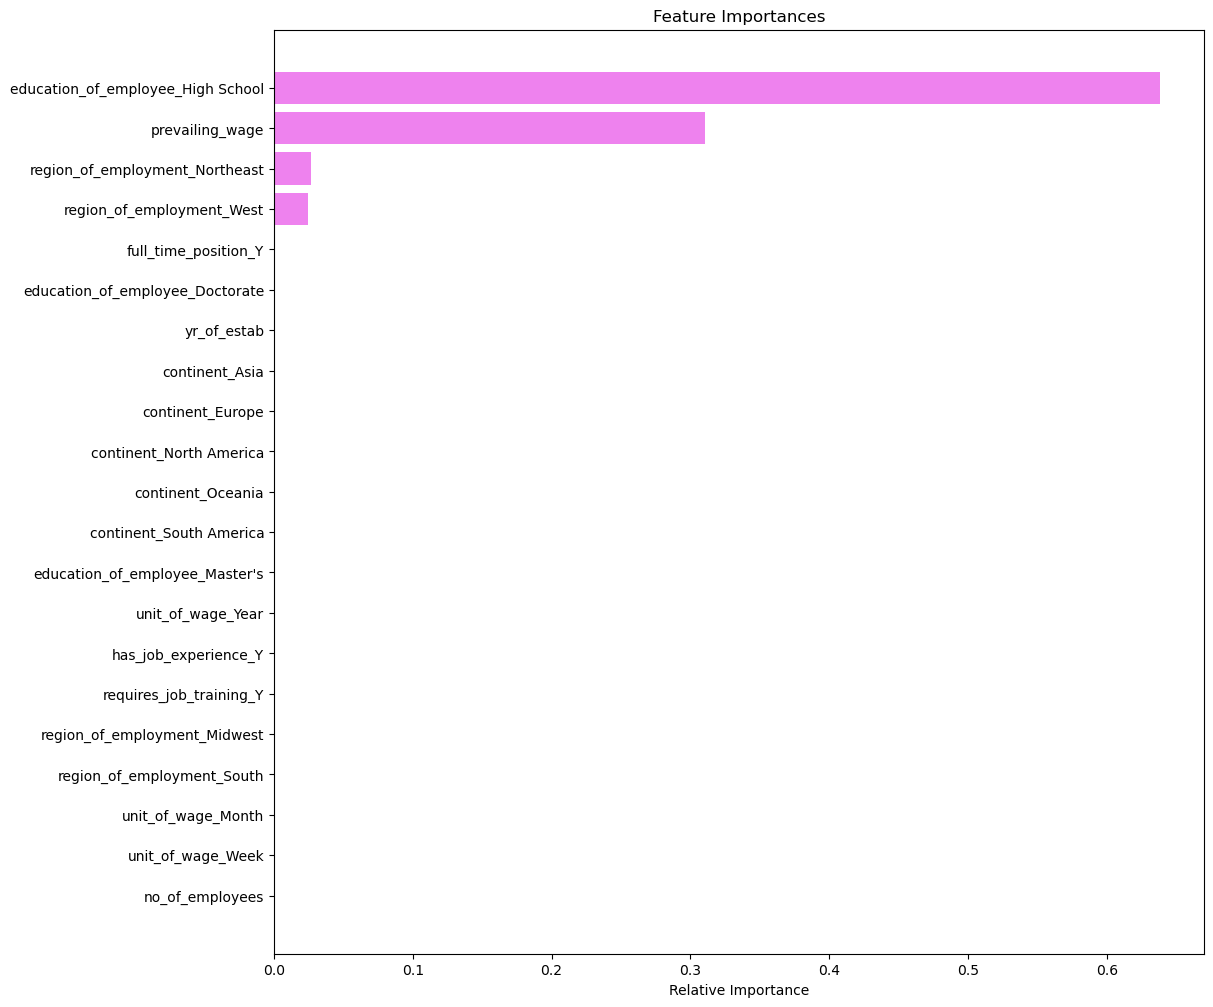

In [97]:
feature_names = X_train.columns
importances = final_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Final Model Summary and Insights

### Compare the Performance of Tuned Models

Multiple models were trained and tuned, including AdaBoost, Gradient Boosting, Random Forest, and others using original, oversampled, and undersampled data.

- **AdaBoost (Tuned)** achieved the highest recall (~0.93) on validation and test data  
- **Gradient Boosting (Tuned)** performed strongly with recall (~0.89) but slightly lower than AdaBoost  
- **Random Forest (Tuned)** showed balanced performance but lower recall (~0.74)  
- Models trained on **original data outperformed oversampled and undersampled versions** overall  

👉 Based on the business objective (maximize recall), **AdaBoost was selected as the final model**

---

### Overview of Final ML Model and its Parameters

The final selected model is **Tuned AdaBoost Classifier**

**Key Characteristics:**
- Ensemble model combining weak learners (decision trees)
- Focuses on correcting previous errors iteratively
- Optimized for recall using RandomizedSearchCV

**Tuned Parameters (search space):**
- n_estimators: [50, 75, 100, 125]  
- learning_rate: [1.0, 0.5, 0.1, 0.01]  
- base estimator depth: 1–3  

👉 The final model uses the **best parameter combination identified during tuning**

---

### Performance of Final Model (Test Data)

- Accuracy: **0.712**  
- Recall: **0.931**  
- Precision: **0.720**  
- F1 Score: **0.812**  

---

### Comment on Final Model Performance

- The model achieves **very high recall (~93%)**, meaning it successfully identifies most Certified visa applications  
- Precision is moderate, indicating some false positives, but still acceptable  
- The model generalizes well from training → validation → test  
- No signs of overfitting  

👉 This is ideal because **missing qualified candidates is more costly than reviewing extra applications**

---

### Summary of Most Important Factors

From feature importance analysis, the key drivers of visa certification are:

1. **education_of_employee_High School**
2. **prevailing_wage**
3. **region_of_employment (Northeast, West)**

---

### Interpretation of Key Drivers

- **Education level** plays the largest role in prediction  
- **Prevailing wage** strongly influences approval likelihood  
- **Region of employment** has moderate influence  
- Other features (experience, company size, etc.) have relatively lower impact  

---

### Business Insight

- Applicants with stronger education and higher wages are more likely to be certified  
- The model can help **prioritize high-probability candidates**  
- It reduces manual workload by focusing attention on the most promising applications  

---

### Final Summary

- **AdaBoost is the best-performing model** for this problem  
- It aligns with the business objective by maximizing recall  
- The model is reliable, interpretable, and effective for decision support  

👉 This model can be used by EasyVisa to **streamline visa application screening and improve decision-making efficiency**

## Actionable Insights and Recommendations

- This section can be attempted directly in the presentation.

<font size=6 color='blue'>Power Ahead</font>
___